Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [1]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

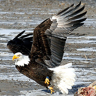
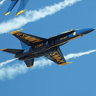
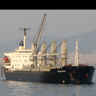
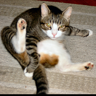

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

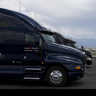
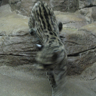
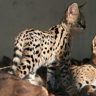
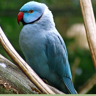

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [6]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [7]:
BATCH_SIZE = 32

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Baseline Model

In [8]:
def train_model(model, train_data, val_data, model_name="Model"):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    # Callbacks for tuning
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=25,
        callbacks=callbacks
    )
    return history

    

In [9]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object [cite: 230]
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [10]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        # 1. First Convolutional Block
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 2. Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 3. Third Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 4. Flatten and Dense Layers for Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [11]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

baseline = build_baseline_model(img_shape, num_classes)
baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25


125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.1915 - loss: 2.1166 - val_accuracy: 0.3330 - val_loss: 1.7428
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.3917 - loss: 1.6023 - val_accuracy: 0.4490 - val_loss: 1.4777
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4980 - loss: 1.3463 - val_accuracy: 0.4620 - val_loss: 1.4433
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5840 - loss: 1.1585 - val_accuracy: 0.5340 - val_loss: 1.3097
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6588 - loss: 0.9609 - val_accuracy: 0.5400 - val_loss: 1.3261
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6963 - loss: 0.8373 - val_accuracy: 0.5370 - val_loss: 1.3898
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7633 - loss: 0.6615 - val_accuracy: 0.5520 - val_loss: 1.4172
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8191 - loss: 0.5185 - val_accuracy: 0.

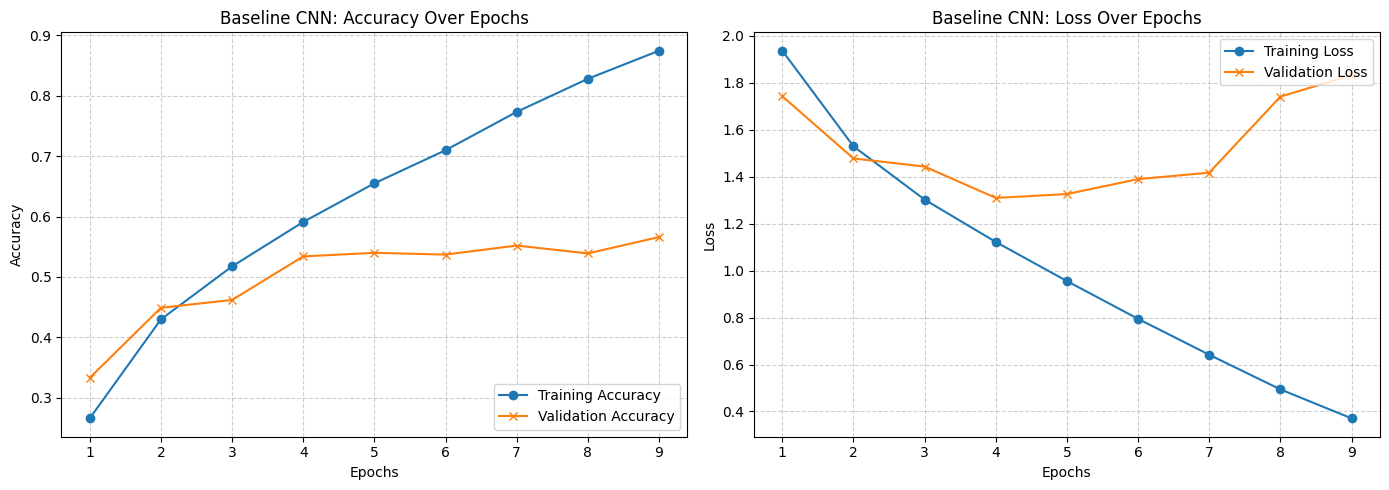

In [12]:
history = train_model(baseline, train_data, val_data, model_name="Baseline CNN")
plot_history(history, model_name="Baseline CNN")

In [13]:
test_loss, test_accuracy = baseline.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5338 - loss: 1.3301
Test Accuracy: 53.66%
Test Loss: 1.3214


# Custom CNN

Added Droupout

In [14]:
from tensorflow.keras import layers, models

input_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

# Added Dropout

model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 3. Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
        
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.1415 - loss: 2.2701 - val_accuracy: 0.2800 - val_loss: 1.9007
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.2717 - loss: 1.9369 - val_accuracy: 0.3550 - val_loss: 1.6866
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.3256 - loss: 1.7403 - val_accuracy: 0.3950 - val_loss: 1.5471
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3941 - loss: 1.5932 - val_accuracy: 0.4330 - val_loss: 1.4438
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.4330 - loss: 1.4641 - val_accuracy: 0.4360 - val_loss: 1.5550
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4786 - loss: 1.3707 - val_accuracy: 0.5130 - val_loss: 1.3652
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4926 - loss: 1.3014 - val_accuracy: 0.5120 - val_loss: 1.3451
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5212 - loss: 1.2560 - val_ac

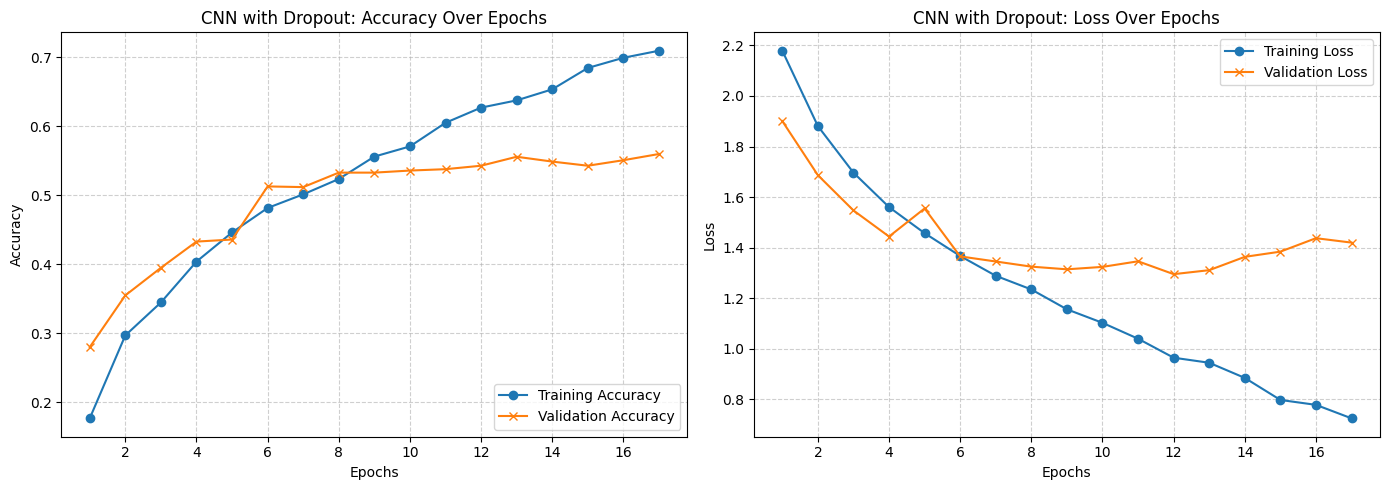

In [15]:
history = train_model(model, train_data, val_data, model_name="CNN with Dropout")
plot_history(history, model_name="CNN with Dropout")

In [16]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5409 - loss: 1.3192
Test Accuracy: 54.81%
Test Loss: 1.3145


Data Augmentation

In [17]:
from tensorflow.keras import layers, models

input_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

# Added Dropout

model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),

    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),


    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 3. Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
        
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
        
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.1593 - loss: 2.2079 - val_accuracy: 0.2850 - val_loss: 1.8987
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.2816 - loss: 1.8942 - val_accuracy: 0.3480 - val_loss: 1.6590
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.3244 - loss: 1.7648 - val_accuracy: 0.3940 - val_loss: 1.6188
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3501 - loss: 1.6823 - val_accuracy: 0.3840 - val_loss: 1.6613
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3754 - loss: 1.6418 - val_accuracy: 0.4160 - val_loss: 1.5257
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.3938 - loss: 1.5884 - val_accuracy: 0.4670 - val_loss: 1.4101
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.4094 - loss: 1.5504 - val_accuracy: 0.4800 - val_loss: 1.3833
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4383 - loss: 1.5031 - val_ac

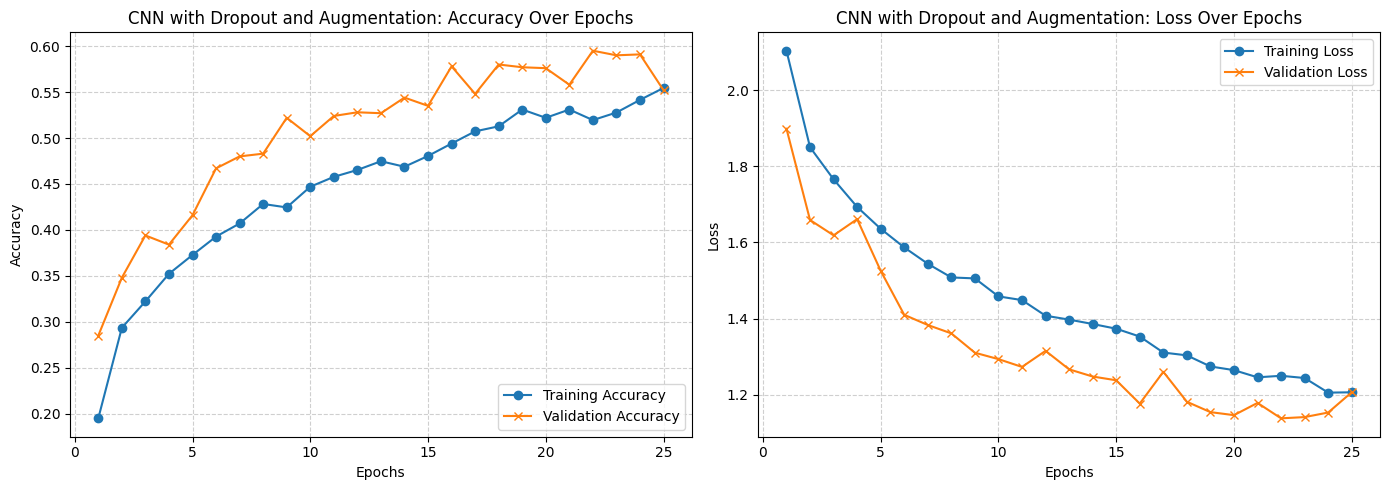

In [18]:
history = train_model(model, train_data, val_data, model_name="CNN with Dropout and Augmentation")
plot_history(history, model_name="CNN with Dropout and Augmentation")

In [19]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5721 - loss: 1.1791
Test Accuracy: 58.04%
Test Loss: 1.1667


# Pretrained CNN